# Covarience Matrix Adaptation Evolution Strategy (CMA-ES)

Este notebook tem como objetivo introduzir o método de otimização por Adaptação de Matriz de Covariância, utilizando funções clássicas para estabelecer um *baseline* para futuros Benchmarks.

**Autor:** Edélio Gabriel Magalhães de Jesus.

## Introdução

## MADS (Mesh Adaptive Direct Search)

O MADS (*Mesh Adaptive Direct Search*) é um algoritmo de otimização direta para funções contínuas de caixa-preta, proposto por Charles Audet e John E. Dennis Jr. em meados da década de 2000. Ele pertence à família dos métodos de busca direta (*direct search methods*), que não utilizam derivadas, sendo especialmente adequado para problemas onde a função objetivo é não-diferenciável, descontínua, ruidosa ou extremamente cara de avaliar.

### A ideia central

O algoritmo mantém uma **malha (*mesh*)** discreta no espaço de busca, que é refinada ou expandida dinamicamente conforme a exploração avança. A cada iteração, o MADS executa duas etapas principais:

1. **Busca (*search*)**: etapa opcional e flexível que pode utilizar qualquer estratégia heurística (como busca aleatória, polling, ou até mesmo outros algoritmos) para explorar pontos promissores na malha.
2. **Polling (*poll*)**: etapa obrigatória que avalia sistematicamente um conjunto de direções ao redor do ponto atual, formando um padrão (*pattern*) que garante convergência teórica.

### O mecanismo da malha

A malha é definida como um conjunto discreto de pontos:

$$M_k = \{ x_k + \Delta_k^m D z : z \in \mathbb{N}^{n_D} \}$$

onde $x_k$ é o ponto central atual, $\Delta_k^m$ é o tamanho da malha (*mesh size*), $D$ é uma matriz de direções geradoras e $n_D$ é o número dessas direções. O parâmetro $\Delta_k^p$ (tamanho do poll) controla a distância dos pontos avaliados no polling.

A cada iteração:

- **Se um ponto melhor é encontrado**: o algoritmo mantém ou expande a malha, movendo o ponto central para a nova solução.
- **Se nenhum ponto melhor é encontrado**: a malha é refinada (tamanho reduzido), concentrando a busca na vizinhança do ponto atual.

### Adaptação da malha

O MADS utiliza dois parâmetros de tamanho distintos:

- **Tamanho da malha ($\Delta_k^m$)**: controla a densidade da malha. Diminui quando o polling falha em encontrar melhores pontos.
- **Tamanho do poll ($\Delta_k^p$)**: controla a distância dos pontos avaliados no polling. É sempre $\Delta_k^p \geq \Delta_k^m$, permitindo que a busca explore tanto finamente quanto mais amplamente.

A atualização segue a regra:

$$x_{k+1} = 
\begin{cases} 
x_k + d_k & \text{se } f(x_k + d_k) < f(x_k) \text{ para algum } d_k \in P_k \\
x_k & \text{caso contrário}
\end{cases}
$$

onde $P_k$ é o conjunto de direções de polling. O tamanho da malha é então atualizado como:

$$\Delta_{k+1}^m = 
\begin{cases} 
\tau \Delta_k^m & \text{se sucesso (expansão)} \\
\Delta_k^m / \tau & \text{se falha (refinamento)}
\end{cases}
$$

com $\tau > 1$ tipicamente igual a 2 ou 4.

### Direções e padrões

O MADS se diferencia de métodos anteriores (como o GPS - *Generalized Pattern Search*) por permitir um conjunto mais rico de direções:

- **Direções finas (*refining directions*)**: garantem que o polling pode se concentrar em direções específicas quando a malha é refinada.
- **Direções ricas (*rich directions*)**: permitem que o polling avalie pontos em direções que não estão necessariamente alinhadas com a base canônica.

Na prática, o MADS gera direções como:

$$D_k = \left[ \begin{array}{cccc} 
1 & 0 & \cdots & 0 \\
-1 & 0 & \cdots & 0 \\
0 & 1 & \cdots & 0 \\
0 & -1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 1 \\
0 & 0 & \cdots & -1 
\end{array} \right] \cdot \Delta_k^p + \text{direções extras}$$

Para problemas com restrições, o MADS incorpora mecanismos adicionais como **barreiras progressivas (*progressive barrier*)** e **extremos (*extreme barrier*)**, que tratam pontos inviáveis de forma diferenciada.

### Complexidade e limitações

O MADS é computacionalmente leve em cada iteração: o custo dominante é a avaliação da função objetivo nos pontos do polling, que normalmente é $O(2n)$ ou $O(4n)$ por iteração, onde $n$ é a dimensão do problema. O algoritmo não requer armazenamento de matrizes ou histórico extenso, tornando-o adequado para problemas de alta dimensão (centenas ou milhares de variáveis) desde que o orçamento de avaliações seja controlado.

**Principais limitações:**

- Convergência mais lenta em problemas bem-comportados comparado a métodos baseados em gradiente
- Sensibilidade à escolha dos parâmetros iniciais ($\Delta^m$, $\Delta^p$, $\tau$)
- O desempenho degrada em superfícies extremamente mal-condicionadas, onde a adaptação da malha pode ser insuficiente
- A etapa opcional de *search* pode exigir ajustes específicos para cada problema

### Variações e extensões

- **Ortho-MADS**: utiliza direções ortonormais geradas a partir de matrizes de Hadamard ou Householder, garantindo melhor exploração do espaço de busca.
- **LTMADS (*LTM ADS*)**: variante que utiliza um número reduzido de direções para problemas de alta dimensão.
- **Multiobjetivo MADS**: extensão para problemas com múltiplas funções objetivo, mantendo uma frente de Pareto.
- **MADS com busca Bayesian**: incorpora modelos substitutos (*surrogate models*) para reduzir o número de avaliações caras.

## Módulos disponíveis

### **pycma**

Desenvolvido por Nikolaus Hansen [[1]](#ref-pycma), essa é a biblioteca mais completa e fiel ao método de otimização CMA-ES. Dessa forma, possui suporte à restrições lineares e não lineares, ruído e variáveis discretas.

Como é uma implementação robusta, ele possui um tempo de convergência menor do que outros módulos implementados.

### **cmaes**

Desenvolvido mais recentemente por Nomura et al. [[2]](#ref-cmaes), o módulo tem a proposta de possibilitar uma implementação do método de forma mais simples, leve e rápida. Sua API é minimalista e permite a integração com o *framework* Optuna, muito usado em problemas de otimização em *Machine Learning*.

Em contrapartida, por ter a proposta de simplicidade e acessibilidade, é menos completo quando comparado ao *pycma*, com *features* limitadas - como a ausência de métodos para implementação de resrições não lineares.

---

Faremos um pequeno benchmark entre os dois métodos!

## Função de *baseline*

### **Ackley Function**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/ackley.png" alt="Função de Ackley" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

In [10]:
import numpy as np

In [11]:
def ackley(x):
    x = np.array(x)
    n = len(x)
    return (
        -20 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / n))
        - np.exp(np.sum(np.cos(2 * np.pi * x)) / n)
        + 20 + np.e
    )

## Função de *Benchmarking*

In [12]:
import time

def bench(optimizer_fn, n_iter, base_seed=367):

    resultados = []

    for i in range(n_iter):
        seed = base_seed + i
        start = time.time()
        best, evals, _ = optimizer_fn(seed=seed)
        elapsed = time.time() - start

        resultados.append({
            'best': best,
            'evals': evals,
            'time': elapsed
        })

    return resultados

## Função para o uso do *pycma*

In [13]:
import cma

In [14]:
def run_pycma(dim, max_evals, sigma, seed=None):
    evals = 0
    historico = []

    rng = np.random.default_rng(seed)

    def f(x):
        nonlocal evals
        evals += 1
        return ackley(x)

    x0 = rng.uniform(-5, 5, dim)
    popsize = 4 + int(3 * np.log(dim))

    optimizer = cma.CMAEvolutionStrategy(
        x0, sigma,
        {'popsize': popsize, 'verb_disp': 0, 'seed': int(seed) if seed is not None else 0}
    )

    best = float("inf")

    while evals + popsize <= max_evals:
        X = optimizer.ask()
        fvals = [f(x) for x in X]

        optimizer.tell(X, fvals)

        best = min(best, min(fvals))
        historico.append(best)

    return best, evals, historico

## Função para usar *cmaes*

In [15]:
from cmaes import CMA

In [16]:
def run_cmaes(dim, max_evals, sigma, seed=None):
    evals = 0
    historico = []

    rng = np.random.default_rng(seed)

    def f(x):
        nonlocal evals
        evals += 1
        return ackley(x)

    x0 = rng.uniform(-5, 5, dim)

    optimizer = CMA(
        mean=x0,
        sigma=sigma,
        seed=int(seed) if seed is not None else 0
    )

    popsize = optimizer.population_size
    best = float("inf")

    while evals + popsize <= max_evals:
        solutions = []

        for _ in range(popsize):
            x = optimizer.ask()
            value = f(x)

            best = min(best, value)
            solutions.append((x, value))

        optimizer.tell(solutions)

        historico.append(best)

    return best, evals, historico

## Comparando

In [17]:
SEED = 367
sigma = 1
dim = 20
max_evals = 10000
n_iter = 100

C:\Users\edelio25024\AppData\Local\Temp\ipykernel_26376\1650424145.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(


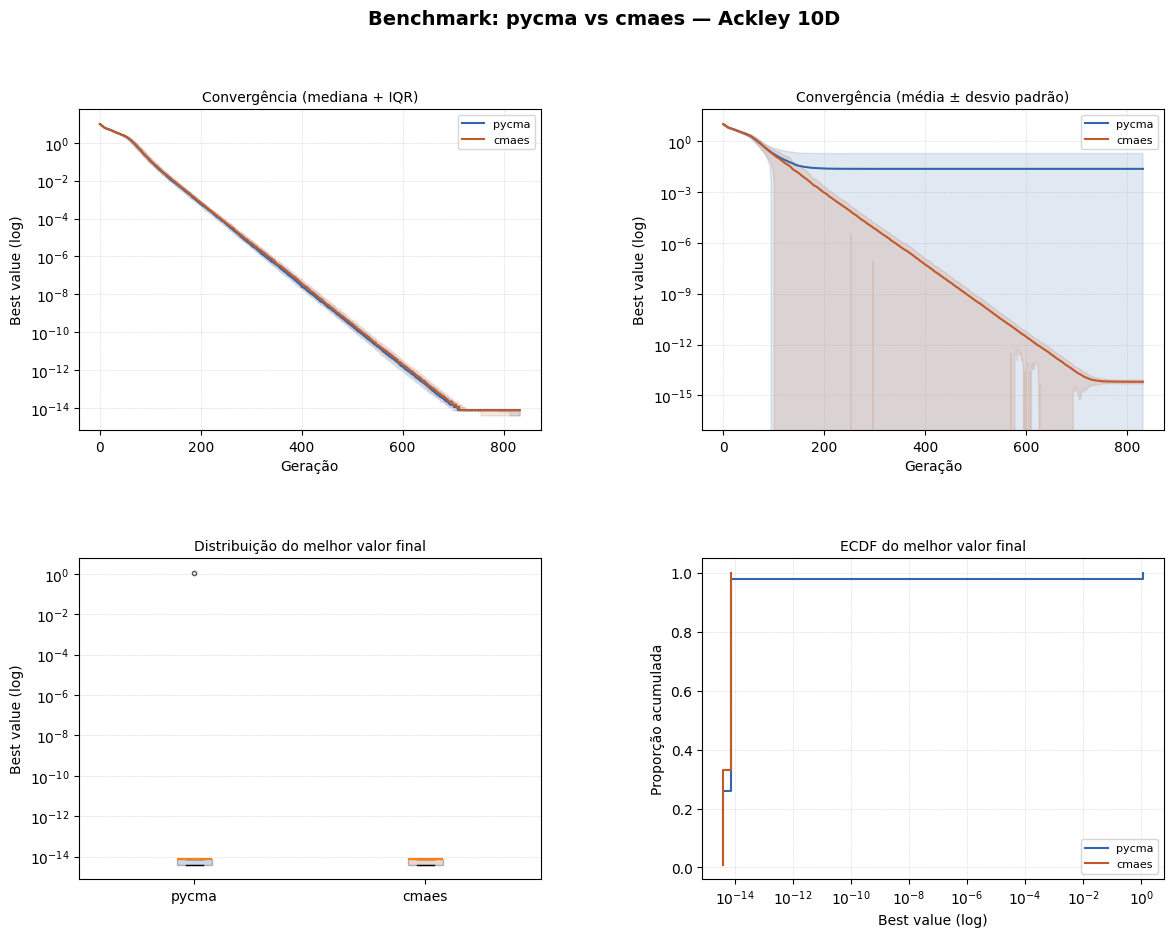

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- rodar as execuções ---
hist_pycma = []
hist_cmaes = []

for i in range(n_iter):
    seed = SEED + i
    _, _, h1 = run_pycma(dim, max_evals, sigma, seed=seed)
    _, _, h2 = run_cmaes(dim, max_evals, sigma, seed=seed)
    hist_pycma.append(h1)
    hist_cmaes.append(h2)

# --- dados ---
mean_pycma   = np.mean(hist_pycma, axis=0)
mean_cmaes   = np.mean(hist_cmaes, axis=0)
std_pycma    = np.std(hist_pycma, axis=0)
std_cmaes    = np.std(hist_cmaes, axis=0)
median_pycma = np.median(hist_pycma, axis=0)
median_cmaes = np.median(hist_cmaes, axis=0)
q1_pycma     = np.percentile(hist_pycma, 25, axis=0)
q3_pycma     = np.percentile(hist_pycma, 75, axis=0)
q1_cmaes     = np.percentile(hist_cmaes, 25, axis=0)
q3_cmaes     = np.percentile(hist_cmaes, 75, axis=0)
x            = np.arange(len(mean_pycma))
best_pycma   = [min(run) for run in hist_pycma]
best_cmaes   = [min(run) for run in hist_cmaes]

# --- painel ---
COLOR_PY = "#3266ad"
COLOR_CM = "#c05a2a"

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Benchmark: pycma vs cmaes — Ackley 10D", fontsize=14, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# gráfico 1: convergência (mediana + IQR)
ax1.plot(x, median_pycma, color=COLOR_PY, label="pycma", linewidth=1.5)
ax1.fill_between(x, q1_pycma, q3_pycma, color=COLOR_PY, alpha=0.15)
ax1.plot(x, median_cmaes, color=COLOR_CM, label="cmaes", linewidth=1.5)
ax1.fill_between(x, q1_cmaes, q3_cmaes, color=COLOR_CM, alpha=0.15)
ax1.set_yscale("log")
ax1.set_title("Convergência (mediana + IQR)", fontsize=10)
ax1.set_xlabel("Geração")
ax1.set_ylabel("Best value (log)")
ax1.legend(fontsize=8)
ax1.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)

# gráfico 2: convergência (média + desvio padrão)
ax2.plot(x, mean_pycma, color=COLOR_PY, label="pycma", linewidth=1.5)
ax2.fill_between(x, mean_pycma - std_pycma, mean_pycma + std_pycma, color=COLOR_PY, alpha=0.15)
ax2.plot(x, mean_cmaes, color=COLOR_CM, label="cmaes", linewidth=1.5)
ax2.fill_between(x, mean_cmaes - std_cmaes, mean_cmaes + std_cmaes, color=COLOR_CM, alpha=0.15)
ax2.set_yscale("log")
ax2.set_title("Convergência (média ± desvio padrão)", fontsize=10)
ax2.set_xlabel("Geração")
ax2.set_ylabel("Best value (log)")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)

# gráfico 3: distribuição do melhor valor final (boxplot)
bp = ax3.boxplot(
    [best_pycma, best_cmaes],
    labels=["pycma", "cmaes"],
    patch_artist=True,
    medianprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
for patch, color in zip(bp["boxes"], [COLOR_PY, COLOR_CM]):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)
ax3.set_yscale("log")
ax3.set_title("Distribuição do melhor valor final", fontsize=10)
ax3.set_ylabel("Best value (log)")
ax3.grid(True, axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

# gráfico 4: ECDF do melhor valor final
def ecdf(data):
    xs = np.sort(data)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys

xs_py, ys_py = ecdf(best_pycma)
xs_cm, ys_cm = ecdf(best_cmaes)
ax4.step(xs_py, ys_py, color=COLOR_PY, label="pycma", linewidth=1.5, where="post")
ax4.step(xs_cm, ys_cm, color=COLOR_CM, label="cmaes", linewidth=1.5, where="post")
ax4.set_xscale("log")
ax4.set_title("ECDF do melhor valor final", fontsize=10)
ax4.set_xlabel("Best value (log)")
ax4.set_ylabel("Proporção acumulada")
ax4.legend(fontsize=8)
ax4.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)

plt.show()

## Referências

<a id="ref-pycma"></a> [1] [CMA-ES/pycma on Github](https://doi.org/10.5281/zenodo.2559634)

<a id='ref-cmaes'></a> [2] [cmaes: A Simple yet Practical Python Library for CMA-ES](https://arxiv.org/abs/2402.01373)